# Sequence-to-Sequence

solving seq2seq problem using encoder-decoder model...

## Convert “21st October 2025” → “2025-10-21”

### Import libraries

In [1]:
import numpy as np
import tensorflow as tf
import random

2025-10-22 09:17:57.349578: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-22 09:17:57.398699: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-22 09:17:59.514118: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Build Vocabulary

In [2]:
# Character vocabularies
input_chars = list("0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ ,")
output_chars = list("0123456789-")

input_vocab = {ch: i for i, ch in enumerate(input_chars)}
output_vocab = {ch: i for i, ch in enumerate(output_chars)}
inv_output_vocab = {i: ch for ch, i in output_vocab.items()}

In [3]:
INPUT_DIM = len(input_vocab)
OUTPUT_DIM = len(output_vocab)
MAX_INPUT_LEN = 30
MAX_OUTPUT_LEN = 10
HIDDEN_DIM = 64

print(INPUT_DIM, OUTPUT_DIM)

64 11


### Generate Data

In [4]:
def generate_date_pair():
    months = ["January", "February", "March", "April", "May", "June",
              "July", "August", "September", "October", "November", "December"]
    day = random.randint(1, 28)
    month = random.choice(months)
    year = random.randint(2000, 2025)

    input_str = f"{day} {month} {year}"
    output_str = f"{year:04d}-{months.index(month)+1:02d}-{day:02d}"
    
    return input_str, output_str

# example usage
a,b = generate_date_pair()
print("Input:", a)
print("Output:", b)

Input: 19 June 2015
Output: 2015-06-19


In [5]:
def encode_seq(seq, vocab, max_len):
    seq = seq[:max_len].ljust(max_len)
    return [vocab[ch] for ch in seq]

# example usage
len(encode_seq("12 January 2020", input_vocab, MAX_INPUT_LEN))

30

In [6]:
# Create full training dataset
def build_dataset(num_samples=5000):
    encoder_input_data = []
    decoder_input_data = []
    decoder_target_data = []

    for _ in range(num_samples):
        # generate input and output string pair
        in_str, out_str = generate_date_pair()

        # encode input and output strings using vocabularies and fixed lengths
        enc = encode_seq(in_str, input_vocab, MAX_INPUT_LEN)
        dec = encode_seq(out_str, output_vocab, MAX_OUTPUT_LEN)

        # append to dataset lists
        encoder_input_data.append(enc)
        decoder_target_data.append(dec)
        decoder_input_data.append([output_vocab["-"]] + dec[:-1])
        
    return (
        np.array(encoder_input_data),
        np.array(decoder_input_data),
        np.expand_dims(np.array(decoder_target_data), -1)
        )

| Timestep | Decoder Input | Decoder Target | Model's Goal                                      |
|----------|----------------|----------------|---------------------------------------------------|
| t = 0    | "-"            | "2"            | Predict "2" given "-" and encoder context         |
| t = 1    | "2"            | "0"            | Predict "0" given "2"                             |
| t = 2    | "0"            | "..."          | Predict "2" given "0"                             |
| ...      | ...            | ...            | ...                                               |

### Let's dive into the model

In [7]:
# Build dataset
X_enc, X_dec, Y_dec = build_dataset()

In [8]:
# Model architecture
encoder_inputs = tf.keras.Input(shape=(MAX_INPUT_LEN,))
enc_emb = tf.keras.layers.Embedding(INPUT_DIM, HIDDEN_DIM)(encoder_inputs)
_, state_h, state_c = tf.keras.layers.LSTM(HIDDEN_DIM, 
                                           return_state=True)(enc_emb)


decoder_inputs = tf.keras.Input(shape=(MAX_OUTPUT_LEN,))
dec_emb = tf.keras.layers.Embedding(OUTPUT_DIM, HIDDEN_DIM)(decoder_inputs)
decoder_outputs, state_h, state_c = tf.keras.layers.LSTM(HIDDEN_DIM, 
                                       return_sequences=True, 
                                       return_state=True)(dec_emb, initial_state=[state_h, state_c])

decoder_outputs = tf.keras.layers.Dense(OUTPUT_DIM, activation='softmax')(decoder_outputs)

model = tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

2025-10-22 09:18:01.635707: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 64)    │      4,096 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 10, 64)    │        704 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 64),      │     33,024 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 10, 64),  │     33,024 │ embedding_1[0][0… │
│                     │ (None, 64),       │            │ lstm[0][1],       │
│                     │ (None, 64)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 11)    │        715 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 71,563 (279.54 KB)

 Trainable params: 71,563 (279.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train
model.fit([X_enc, X_dec], Y_dec, batch_size=64, epochs=10)

Epoch 1/10


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1.5550
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1.0174
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.9425
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.8574
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.7091
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.5428
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.4120
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.2928
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.1979
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1301


### Inference

In [11]:
model.layers

[<InputLayer name=input_layer, built=True>,
 <InputLayer name=input_layer_1, built=True>,
 <Embedding name=embedding, built=True>,
 <Embedding name=embedding_1, built=True>,
 <LSTM name=lstm, built=True>,
 <LSTM name=lstm_1, built=True>,
 <Dense name=dense, built=True>]

| Layer Index         | Layer Type   | Role in Model              |
|---------------------|--------------|-----------------------------|
| `model.layers[0]`   | InputLayer   | Encoder input               |
| `model.layers[1]`   | InputLayer   | Decoder input               |
| `model.layers[2]`   | Embedding    | Encoder embedding           |
| `model.layers[3]`   | Embedding    | Decoder embedding           |
| `model.layers[4]`   | LSTM         | Encoder LSTM                |
| `model.layers[5]`   | LSTM         | Decoder LSTM                |
| `model.layers[6]`   | Dense        | Decoder output layer        |

In [12]:
def predict_date(input_str):
    # Step 1: Encode input string
    enc_input = np.array([encode_seq(input_str, input_vocab, MAX_INPUT_LEN)])

    # Step 2: Run encoder to get initial states
    encoder_emb = model.layers[2](enc_input)  # Encoder embedding
    _, state_h, state_c = model.layers[4](encoder_emb)  # Encoder LSTM

    # Step 3: Initialize decoder input with start token ("-")
    target_seq = np.array([[output_vocab["-"]]])
    result = []

    # Step 4: Generate output sequence token-by-token
    for _ in range(MAX_OUTPUT_LEN):
        decoder_emb = model.layers[3](target_seq)  # Decoder embedding
        decoder_output, state_h, state_c = model.layers[5](decoder_emb, initial_state=[state_h, state_c])  # Decoder LSTM
        output_token = model.layers[6](decoder_output)  # Dense layer

        # Step 5: Choose highest probability token
        sampled_token_index = np.argmax(output_token[0, -1, :])
        result.append(inv_output_vocab[sampled_token_index])

        # Step 6: Update decoder input for next timestep
        target_seq = np.array([[sampled_token_index]])

    return ''.join(result)

In [13]:

print("Input:", "21 October 2025")
print("Predicted:", predict_date("21 October 2025"))

Input: 21 October 2025


Predicted: 2025-10-21


## Univariate Time-Series Forecasting using LSTM

### Import libraries

In [14]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten

### Define univariate time series

In [15]:
# dataset
# define input sequence
timeseries_data = [110, 125, 133, 146, 158, 172, 187, 196, 210]

### Data preprocessing

In [16]:
# preparing independent and dependent features
def prepare_data(timeseries_data, n_features):
	X, y =[],[]
	for i in range(len(timeseries_data)):
		# find the end of this pattern
		end_ix = i + n_features
		# check if we are beyond the sequence
		if end_ix > len(timeseries_data)-1:
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = timeseries_data[i:end_ix], timeseries_data[end_ix]
		X.append(seq_x)
		y.append(seq_y)
	return np.array(X), np.array(y)

In [17]:
n_steps = 3
X, y = prepare_data(timeseries_data, n_steps)

print(X.shape, y.shape)

(6, 3) (6,)


In [18]:
X,y

(array([[110, 125, 133],
        [125, 133, 146],
        [133, 146, 158],
        [146, 158, 172],
        [158, 172, 187],
        [172, 187, 196]]),
 array([146, 158, 172, 187, 196, 210]))

### Reshaping input data

In [19]:
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))
print(X.shape)

(6, 3, 1)


### Building LSTM

**Key Note**
- If we are using last 10 day values and 2 sensor readings to predict tomorrow's temperature, we will use n_steps = 10, and n_features = 2.

> - `LSTM(50)` --> means LSTM layer with 50 memory units (neurons).
>   - Each LSTM unit has cell state (short memory) and several gates that control information flow.
> - `LSTM(50, activation='relu')` --> by default, LSTM uses `tanh` for internal activations and `sigmoid` for gates. With activation set to 'relu', output activation becomes `ReLU` instead of `tanh`.
> - `LSTM(50, activation='relu', return_sequences=True)` --> Return entire sequence of outputs, not just the last time step.
>   - Output shape now --> (n_steps, 50)

In [20]:
model = Sequential()
model.add(LSTM(50, 
               activation='relu', 
               return_sequences=True,
               input_shape=(n_steps, n_features)))  # n_steps --> how many past time steps to use as input
                                                    # n_features --> how many parallel variables per step
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 3, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.fit(X, y, epochs=50, verbose=1)

Epoch 1/50


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 33362.1211
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 33201.9492
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 33026.3008
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 32841.9141
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 32655.7344
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 32460.6777
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 32279.4434
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 32111.2969
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 31917.2676
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 31688.3438
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 31410.3281
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 31051.8496
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 30536.9141
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 29844.3809
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss

### Predict for next 10 days

In [22]:
x_input = np.array([187, 196, 210])
temp_input=list(x_input)
lst_output=[]
i=0
while(i<10):
    if(len(temp_input)>3):
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))

        x_input = x_input.reshape((1, n_steps, n_features))

        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))

        temp_input.append(yhat[0][0])
        temp_input=temp_input[1:]
        lst_output.append(yhat[0][0])
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps, n_features))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.append(yhat[0][0])
        lst_output.append(yhat[0][0])
        i=i+1
    print("\n")
    
print(lst_output)

[268.8412]


1 day input [196.         210.         268.84118652]
1 day output [[289.60626]]


2 day input [210.         268.84118652 289.60626221]
2 day output [[329.11194]]


3 day input [268.8412  289.60626 329.11194]
3 day output [[383.49768]]


4 day input [289.60626 329.11194 383.49768]
4 day output [[425.88815]]


5 day input [329.11194 383.49768 425.88815]
5 day output [[483.68622]]


6 day input [383.49768 425.88815 483.68622]
6 day output [[548.12195]]


7 day input [425.88815 483.68622 548.12195]
7 day output [[614.6839]]


8 day input [483.68622 548.12195 614.6839 ]
8 day output [[693.66327]]


9 day input [548.12195 614.6839  693.66327]
9 day output [[781.76935]]


[np.float32(268.8412), np.float32(289.60626), np.float32(329.11194), np.float32(383.49768), np.float32(425.88815), np.float32(483.68622), np.float32(548.12195), np.float32(614.6839), np.float32(693.66327), np.float32(781.76935)]


## Key Points related to LSTM

### Basics

> - LSTM expects input to be 3D tensor [batch_size, n_steps, n_features]
> - LSTM has `4 dense layers` in its internal structure

### Parameter calculation in LSTM

In [23]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM

timesteps=40           # dimensionality of the input sequence
features=3            # dimensionality of each input representation in the sequence
LSTMoutputDimension = 2 # dimensionality of the LSTM outputs (Hidden & Cell states)

input = Input(shape=(timesteps, features))
output= LSTM(LSTMoutputDimension)(input)
model_LSTM = Model(inputs=input, outputs=output)

model_LSTM.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 40, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 2)              │            48 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48 (192.00 B)

 Trainable params: 48 (192.00 B)

 Non-trainable params: 0 (0.00 B)

- In dense layer, considering i (input size), h (size of hidden layer) and o (output size)
  - number of parameters = i*(h) + h + h*(o)+o = h*(i+o)+ (o+h)
- considering 3 units in input layer, 5 units in hidden layer and 2 units in output layer,
  - total parameters = 3x5+5 + 5x2+2 = 20+12 = 32 

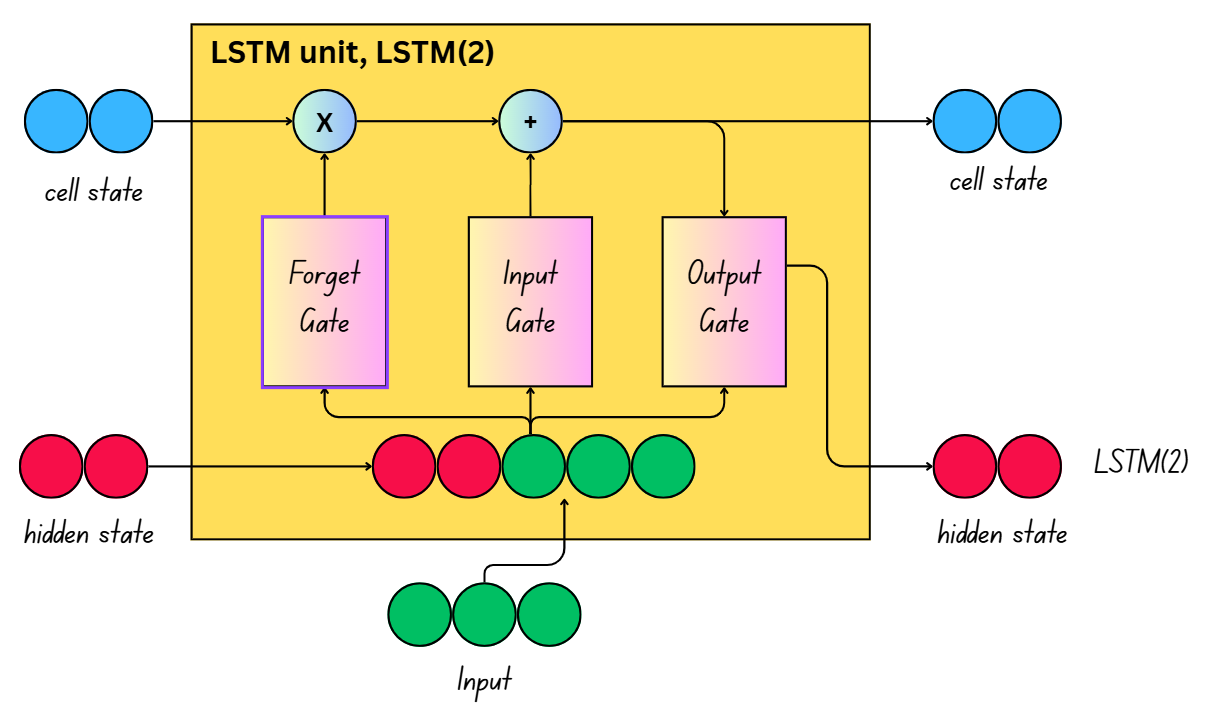

> - Output from all the gates in above example should be of dimension 2, as it should match LSTM units that the user has defined.
> - In the example,
>   - Forget gate,
>     - total 5 numbers are input, and 2 output neurons
>     - 5*2+2 = 12 parameters
>   - Input gate,
>     - 24 parameters
>   - Output gate,
>     - 12 parameters
>   - **Total = 48 parameters**